In [3]:
print(
    nav.shape
)
print(
    benchmark.columns
)
print(
    benchmark.head()
)

(46000, 3)
Index(['date', 'index_name', 'close_value'], dtype='str')
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [4]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(

    ["amfi_code","date"]

)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

print(

    nav[

        ["amfi_code",

         "date",

         "nav",

         "daily_return"]

    ].head(10)

)

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


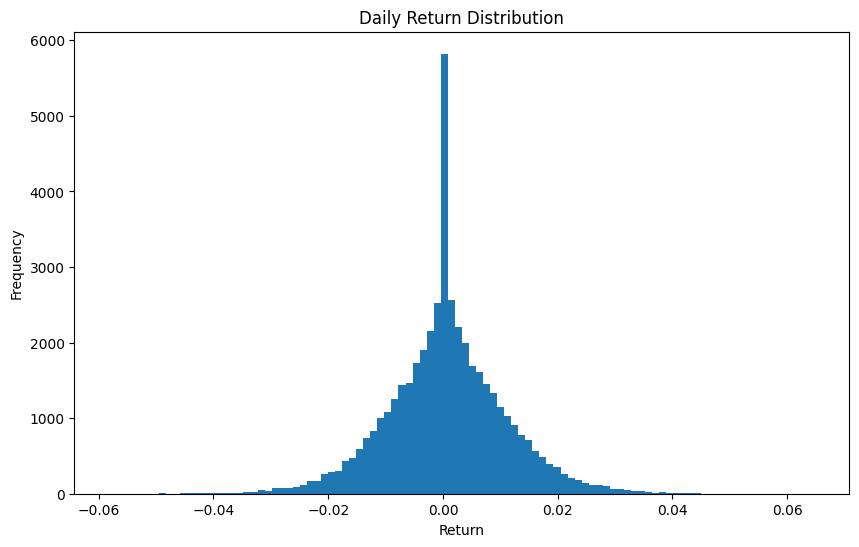

In [5]:
plt.figure(
    figsize=(10,6)
)

plt.hist(

    nav[
        "daily_return"
    ].dropna(),

    bins=100

)

plt.title(
    "Daily Return Distribution"
)

plt.xlabel(
    "Return"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [6]:
cagr_results = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ].sort_values(
        "date"
    )

    start_nav = df["nav"].iloc[0]

    end_nav = df["nav"].iloc[-1]

    years = (
        df["date"].max()
        -
        df["date"].min()
    ).days / 365

    cagr = (
        (end_nav / start_nav)
        **
        (1 / years)
    ) - 1

    cagr_results.append(

        [code,cagr]

    )

cagr_df = pd.DataFrame(

    cagr_results,

    columns=[

        "amfi_code",

        "cagr"

    ]

)

print(
    cagr_df.head()
)

   amfi_code      cagr
0     100016  0.026352
1     100025  0.044551
2     100033  0.300997
3     101206  0.235205
4     101207  0.079331


In [7]:
cagr_df = cagr_df.merge(

    fund[

        ["amfi_code",

         "scheme_name"]

    ],

    on="amfi_code"

)

cagr_df = cagr_df.sort_values(

    "cagr",

    ascending=False

)

print(

    cagr_df.head(10)

)

    amfi_code      cagr                                        scheme_name
25     120505  0.328016           ICICI Pru Midcap Fund - Regular - Growth
21     119598  0.323981         SBI Small Cap Fund - Regular Plan - Growth
39     149324  0.322621              DSP Small Cap Fund - Regular - Growth
36     148569  0.319245      Mirae Asset Tax Saver Fund - Regular - Growth
34     148567  0.309499      Mirae Asset Large Cap Fund - Regular - Growth
30     120843  0.308833             Kotak Flexicap Fund - Regular - Growth
2      100033  0.300997  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38     149323  0.295581                 DSP Midcap Fund - Regular - Growth
16     119094  0.281926                Axis Midcap Fund - Regular - Growth
19     119551  0.257849          SBI Bluechip Fund - Regular Plan - Growth


In [8]:
RF = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = nav[

        nav["amfi_code"] == code

    ][

        "daily_return"

    ].dropna()

    mean_return = returns.mean() * 252

    std_return = returns.std()

    sharpe = (

        mean_return - RF

    ) / (

        std_return

    ) * np.sqrt(252)

    sharpe_results.append(

        [code,sharpe]

    )

sharpe_df = pd.DataFrame(

    sharpe_results,

    columns=[

        "amfi_code",

        "sharpe_ratio"

    ]

)

print(
    sharpe_df.head()
)

   amfi_code  sharpe_ratio
0     100016    -50.782301
1     100025   -142.907888
2     100033    275.612083
3     101206    258.857759
4     101207     40.990514


In [9]:
sharpe_df = sharpe_df.merge(

    fund[

        ["amfi_code",

         "scheme_name"]

    ],

    on="amfi_code"

)

sharpe_df = sharpe_df.sort_values(

    "sharpe_ratio",

    ascending=False

)

print(

    sharpe_df.head(10)

)

    amfi_code  sharpe_ratio                                        scheme_name
34     148567    364.969375      Mirae Asset Large Cap Fund - Regular - Growth
30     120843    329.299480             Kotak Flexicap Fund - Regular - Growth
36     148569    311.202366      Mirae Asset Tax Saver Fund - Regular - Growth
19     119551    304.483175          SBI Bluechip Fund - Regular Plan - Growth
25     120505    297.385502           ICICI Pru Midcap Fund - Regular - Growth
38     149323    285.294707                 DSP Midcap Fund - Regular - Growth
2      100033    275.612083  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9      118632    272.578113     Nippon India Large Cap Fund - Regular - Growth
3      101206    258.857759      ABSL Frontline Equity Fund - Regular - Growth
24     120504    258.684120          ICICI Pru Bluechip Fund - Direct - Growth


In [10]:
sortino_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ][
        "daily_return"
    ].dropna()

    mean_return = returns.mean() * 252

    downside = returns[
        returns < 0
    ]

    downside_std = downside.std()

    sortino = (

        mean_return - RF

    ) / (

        downside_std

    ) * np.sqrt(252)

    sortino_results.append(

        [code,sortino]

    )

sortino_df = pd.DataFrame(

    sortino_results,

    columns=[

        "amfi_code",

        "sortino_ratio"

    ]

)

print(
    sortino_df.head()
)

   amfi_code  sortino_ratio
0     100016     -88.463960
1     100025    -237.338952
2     100033     460.941758
3     101206     453.489844
4     101207      69.714237


In [11]:
sortino_df = sortino_df.merge(

    fund[
        ["amfi_code",
         "scheme_name"]
    ],

    on="amfi_code"

)

sortino_df = sortino_df.sort_values(

    "sortino_ratio",

    ascending=False

)

print(

    sortino_df.head(10)

)

    amfi_code  sortino_ratio  \
34     148567     601.182382   
30     120843     595.808648   
36     148569     541.022309   
19     119551     539.347317   
25     120505     511.396941   
38     149323     472.525468   
9      118632     466.233402   
2      100033     460.941758   
24     120504     454.934036   
3      101206     453.489844   

                                          scheme_name  
34      Mirae Asset Large Cap Fund - Regular - Growth  
30             Kotak Flexicap Fund - Regular - Growth  
36      Mirae Asset Tax Saver Fund - Regular - Growth  
19          SBI Bluechip Fund - Regular Plan - Growth  
25           ICICI Pru Midcap Fund - Regular - Growth  
38                 DSP Midcap Fund - Regular - Growth  
9      Nippon India Large Cap Fund - Regular - Growth  
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
24          ICICI Pru Bluechip Fund - Direct - Growth  
3       ABSL Frontline Equity Fund - Regular - Growth  


In [12]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[

    benchmark["index_name"]

    ==

    "NIFTY100"

].copy()

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = nifty100[
    "close_value"
].pct_change()

print(
    nifty100.head()
)

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [19]:
scorecard["return_rank"] = scorecard[
    "cagr"
].rank(
    pct=True
)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(
    pct=True
)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(
    pct=True
)

scorecard["expense_rank"] = (

    1 -

    scorecard[
        "expense_ratio_pct"
    ].rank(
        pct=True
    )

)

scorecard["drawdown_rank"] = (

    1 -

    scorecard[
        "max_drawdown"
    ].rank(
        pct=True
    )

)

scorecard["fund_score"] = (

      scorecard["return_rank"] * 30

    + scorecard["sharpe_rank"] * 25

    + scorecard["alpha_rank"] * 20

    + scorecard["expense_rank"] * 15

    + scorecard["drawdown_rank"] * 10

)

scorecard = scorecard.sort_values(

    "fund_score",

    ascending=False

)

print(

    scorecard[

        ["scheme_name",

         "fund_score"]

    ].head(10)

)

                                          scheme_name  fund_score
0            ICICI Pru Midcap Fund - Regular - Growth     86.8750
1          SBI Small Cap Fund - Regular Plan - Growth     82.0000
2               DSP Small Cap Fund - Regular - Growth     79.5625
5              Kotak Flexicap Fund - Regular - Growth     78.3750
6   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     77.6250
4       Mirae Asset Large Cap Fund - Regular - Growth     77.1250
3       Mirae Asset Tax Saver Fund - Regular - Growth     76.3125
8                 Axis Midcap Fund - Regular - Growth     74.1250
10     Nippon India Large Cap Fund - Regular - Growth     69.4375
9           SBI Bluechip Fund - Regular Plan - Growth     69.4375


In [20]:
scorecard.to_csv(

    "../Data/processed/fund_scorecard.csv",

    index=False

)

print(
    "Saved"
)

Saved


In [21]:
top5 = scorecard[
    "amfi_code"
].head(5)
print(
    top5
)

0    120505
1    119598
2    149324
5    120843
6    100033
Name: amfi_code, dtype: int64


In [ ]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

bench = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50","NIFTY100"]
    )
].copy()

bench = bench.sort_values(
    "date"
)

bench["normalized"] = bench.groupby(
    "index_name"
)["close_value"].transform(

    lambda x:

    x / x.iloc[0] * 100

)

In [ ]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == code
    ][

        ["date",

         "daily_return"]

    ]

    merged = fund_df.merge(

        nifty100[
            ["date",
             "benchmark_return"]
        ],

        on="date"

    ).dropna()

    if len(merged) > 30:

        slope,intercept,r,p,std = linregress(

            merged[
                "benchmark_return"
            ],

            merged[
                "daily_return"
            ]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [code,
             alpha,
             beta]
        )

alpha_beta_df = pd.DataFrame(

    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]

)

print(
    alpha_beta_df.head()
)

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [24]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

bench = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50","NIFTY100"]
    )
].copy()

bench = bench.sort_values(
    "date"
)

bench["normalized"] = bench.groupby(
    "index_name"
)["close_value"].transform(

    lambda x:

    x / x.iloc[0] * 100

)

print(
    bench.head()
)

           date index_name  close_value  normalized
0    2022-01-03    NIFTY50     17492.79  100.000000
1150 2022-01-03   NIFTY100     17778.24  100.000000
1151 2022-01-04   NIFTY100     17537.52   98.645985
1    2022-01-04    NIFTY50     17689.64  101.125321
2    2022-01-05    NIFTY50     17835.05  101.956578


In [25]:
alpha_beta_df.to_csv(

    "../Data/processed/alpha_beta.csv",

    index=False

)

print(
    "Saved"
)

Saved


In [14]:
alpha_beta_df = alpha_beta_df.merge(

    fund[
        ["amfi_code",
         "scheme_name"]
    ],

    on="amfi_code"

)

print(

    alpha_beta_df.head(10)

)

   amfi_code     alpha      beta  \
0     100016  0.037476 -0.058268   
1     100025  0.042818  0.001158   
2     100033  0.271954  0.005104   
3     101206  0.213998  0.021086   
4     101207  0.108971 -0.065289   
5     101208  0.060861  0.000267   
6     102885  0.170488 -0.019487   
7     102886  0.028969 -0.042125   
8     102887  0.162113  0.016683   
9     118632  0.218294 -0.008354   

                                         scheme_name  
0          HDFC Top 100 Fund - Regular Plan - Growth  
1       HDFC Short Term Debt Fund - Regular - Growth  
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
3      ABSL Frontline Equity Fund - Regular - Growth  
4             ABSL Small Cap Fund - Regular - Growth  
5                ABSL Liquid Fund - Regular - Growth  
6         UTI Nifty 50 Index Fund - Regular - Growth  
7                UTI Mid Cap Fund - Regular - Growth  
8              UTI Flexi Cap Fund - Regular - Growth  
9     Nippon India Large Cap Fund - Regular - Growth 

In [15]:
drawdown_results = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    df = df.sort_values(
        "date"
    )

    df["running_max"] = df[
        "nav"
    ].cummax()

    df["drawdown"] = (

        df["nav"]

        /

        df["running_max"]

    ) - 1

    worst = df.loc[
        df["drawdown"].idxmin()
    ]

    drawdown_results.append(

        [

            code,

            worst["drawdown"],

            worst["date"]

        ]

    )

drawdown_df = pd.DataFrame(

    drawdown_results,

    columns=[

        "amfi_code",

        "max_drawdown",

        "worst_date"

    ]

)

print(
    drawdown_df.head()
)

   amfi_code  max_drawdown worst_date
0     100016     -0.247344 2022-09-15
1     100025     -0.043083 2023-07-28
2     100033     -0.162172 2022-05-12
3     101206     -0.112916 2023-07-05
4     101207     -0.354469 2026-05-11


In [16]:
drawdown_df = drawdown_df.merge(

    fund[
        ["amfi_code",
         "scheme_name"]
    ],

    on="amfi_code"

)

drawdown_df = drawdown_df.sort_values(

    "max_drawdown"

)

print(

    drawdown_df.head(10)

)

    amfi_code  max_drawdown worst_date  \
22     119599     -0.525742 2025-10-28   
17     119095     -0.516778 2026-05-11   
4      101207     -0.354469 2026-05-11   
39     149324     -0.311719 2025-01-03   
21     119598     -0.287060 2025-05-14   
7      102886     -0.280011 2026-04-27   
0      100016     -0.247344 2022-09-15   
29     120842     -0.240035 2024-10-17   
11     118634     -0.233449 2026-02-20   
15     119093     -0.217514 2023-05-22   

                                       scheme_name  
22       SBI Small Cap Fund - Direct Plan - Growth  
17          Axis Small Cap Fund - Regular - Growth  
4           ABSL Small Cap Fund - Regular - Growth  
39           DSP Small Cap Fund - Regular - Growth  
21      SBI Small Cap Fund - Regular Plan - Growth  
7              UTI Mid Cap Fund - Regular - Growth  
0        HDFC Top 100 Fund - Regular Plan - Growth  
29   Kotak Emerging Equity Fund - Regular - Growth  
11  Nippon India Small Cap Fund - Regular - Growth  
15     

In [17]:
scorecard = cagr_df.merge(

    sharpe_df[
        ["amfi_code",
         "sharpe_ratio"]
    ],

    on="amfi_code"

)

scorecard = scorecard.merge(

    alpha_beta_df[
        ["amfi_code",
         "alpha"]
    ],

    on="amfi_code"

)

scorecard = scorecard.merge(

    drawdown_df[
        ["amfi_code",
         "max_drawdown"]
    ],

    on="amfi_code"

)

scorecard = scorecard.merge(

    performance[
        ["amfi_code",
         "expense_ratio_pct"]
    ],

    on="amfi_code"

)

print(
    scorecard.head()
)

   amfi_code      cagr                                    scheme_name  \
0     120505  0.328016       ICICI Pru Midcap Fund - Regular - Growth   
1     119598  0.323981     SBI Small Cap Fund - Regular Plan - Growth   
2     149324  0.322621          DSP Small Cap Fund - Regular - Growth   
3     148569  0.319245  Mirae Asset Tax Saver Fund - Regular - Growth   
4     148567  0.309499  Mirae Asset Large Cap Fund - Regular - Growth   

   sharpe_ratio     alpha  max_drawdown  expense_ratio_pct  
0    297.385502  0.292636     -0.181885               1.36  
1    238.217681  0.303370     -0.287060               1.43  
2    239.348548  0.300579     -0.311719               1.52  
3    311.202366  0.282704     -0.163967               1.60  
4    364.969375  0.269838     -0.112657               1.46  


In [ ]:
scorecard["return_rank"] = scorecard[
    "cagr"
].rank(
    pct=True
)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(
    pct=True
)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(
    pct=True
)

scorecard["expense_rank"] = (

    1 -

    scorecard[
        "expense_ratio_pct"
    ].rank(
        pct=True
    )
)

scorecard["drawdown_rank"] = (

    1 -

    scorecard[
        "max_drawdown"
    ].rank(
        pct=True
    )
)

scorecard["fund_score"] = (
      scorecard["return_rank"] * 30
    + scorecard["sharpe_rank"] * 25
    + scorecard["alpha_rank"] * 20
    + scorecard["expense_rank"] * 15
    + scorecard["drawdown_rank"] * 10
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

print(

    scorecard[
        ["scheme_name",
         "fund_score"]
    ].head(10)
)

                                          scheme_name  fund_score
0            ICICI Pru Midcap Fund - Regular - Growth     86.8750
1          SBI Small Cap Fund - Regular Plan - Growth     82.0000
2               DSP Small Cap Fund - Regular - Growth     79.5625
5              Kotak Flexicap Fund - Regular - Growth     78.3750
6   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     77.6250
4       Mirae Asset Large Cap Fund - Regular - Growth     77.1250
3       Mirae Asset Tax Saver Fund - Regular - Growth     76.3125
8                 Axis Midcap Fund - Regular - Growth     74.1250
10     Nippon India Large Cap Fund - Regular - Growth     69.4375
9           SBI Bluechip Fund - Regular Plan - Growth     69.4375


In [2]:
nav = pd.read_csv(
    "../Data/processed/nav_history_cleaned.csv"
)

performance = pd.read_csv(
    "../Data/processed/scheme_performance_cleaned.csv"
)

benchmark = pd.read_csv(
    "../Data/raw/10_benchmark_indices.csv"
)

fund = pd.read_csv(
    "../Data/raw/01_fund_master.csv"
)

print("Loaded Successfully")

Loaded Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress
print("Libraries Loaded")

Libraries Loaded
